# 10. Curriculum-Aware LLM Analysis: Student 10155
This notebook runs the Curriculum-Aware LLM analysis on student 10155 for all ~50 problems they attempted. 
It uses the same pipeline from `experiments/05b_mental_model_comparison_struggling.ipynb` to compare LLM-generated KC gaps with human annotations.

**Objectives:**
1. Load student 10155's best attempts.
2. Build their Mental Model profile.
3. Generate enriched prompts and call Gemini 2.0 Flash.
4. Compare results with human annotations.
5. Visualize the alignment.

In [ ]:
import os
import sys
import json
import time
import pandas as pd
import matplotlib.pyplot as plt
from typing import List, Dict

# Add project root to path for imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.dataset import load_joined_datasets, get_best_attempts, load_topics_json, load_problem_descriptions
from lib.mental_model import calculate_student_profile, get_weak_skills, build_mental_model_payload
from lib.prompts import build_curriculum_aware_prompt
from google import genai

# Constants
MODEL_ID = "gemini-2.0-flash" 
# Use gemini-2.0-flash as it's the latest confirmed working model
SLEEP_SECONDS = 1.0
STUDENT_ID = 10155
HUMAN_ANNOTATIONS_PATH = "dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_10155_1774736175604.json"
OUTPUT_PATH = "results/human_validation/llm_annotations_10155.json"
VIZ_FOLDER = "results/visualizations/"

# Ensure output directories exist
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
os.makedirs(VIZ_FOLDER, exist_ok=True)

print(f"Environment initialized for Student {STUDENT_ID}")

Environment initialized for Student 10155


In [ ]:
# Load joined datasets and filter for the best attempts of Student 10155
full_dataset = load_joined_datasets("dataset/CodeWorkout/")
best_attempts = get_best_attempts(full_dataset)
student_best_attempts = best_attempts[best_attempts['SubjectID'] == STUDENT_ID]

# Sort by ProblemID for consistency
student_best_attempts = student_best_attempts.sort_values('ProblemID')

print(f"Loaded {len(student_best_attempts)} attempted problems for Student {STUDENT_ID}")
student_best_attempts.head()

Main table: 201,570 rows
CodeState table: 69,627 rows
Subject table: 381 rows
Joined dataset: 191,584 rows
Best attempts: 15,375 rows (372 students, 50 problems)
Loaded 46 attempted problems for Student 10155


,SubjectID,ProblemID,Order,ToolInstances,ServerTimestamp,ServerTimezone,CourseID,CourseSectionID,TermID,AssignmentID,...,EventType,Score,Compile.Result,CompileMessageType,CompileMessageData,EventID,ParentEventID,SourceLocation,Code,X-Grade
1232,10155,1,121075,Java 8; CodeWorkout,2019-02-25T03:30:25,UTC,CS 1114,410.0,spring-2019,439.0,...,Run.Program,1.0000,None,None,None,1-70632,None,None,"public int sortaSum(int a, int b)\r\n{\r\n ...",0.535
1233,10155,3,136525,Java 8; CodeWorkout,2019-02-25T04:01:58,0,CS 1114,410.0,spring-2019,439.0,...,Run.Program,0.8125,None,None,None,3-70297,None,None,"public boolean in1To10(int n, boolean outsideM...",0.535
1234,10155,5,67219,Java 8; CodeWorkout,2019-02-25T02:44:51,UTC,CS 1114,410.0,spring-2019,439.0,...,Run.Program,1.0000,None,None,None,5-37234,None,None,"public boolean answerCell(boolean isMorning, b...",0.535
1235,10155,12,38601,Java 8; CodeWorkout,2019-02-25T04:06:47,0,CS 1114,410.0,spring-2019,439.0,...,Run.Program,1.0000,None,None,None,12-37095,None,None,"public boolean squirrelPlay(int temp, boolean ...",0.535
1236,10155,13,36287,Java 8; CodeWorkout,2019-02-25T04:26:45,UTC,CS 1114,410.0,spring-2019,439.0,...,Run.Program,1.0000,None,None,None,13-64155,None,None,"public int caughtSpeeding(int speed, boolean i...",0.535


In [ ]:
from lib.mental_model import load_skill_map, build_prerequisite_graph

# Load skill map and dependency graph
skill_map, all_skills = load_skill_map("dataset/CodeWorkout/Problem_Prompts/problem_prompts.csv")
prereq_graph = build_prerequisite_graph()

print(f"Loaded skill map with {len(all_skills)} KCs and dependency graph with {len(prereq_graph.edges)} edges.")

Loaded skill map with 18 KCs and dependency graph with 10 edges.


In [ ]:
# Build the student profile based on their performance
student_profile = calculate_student_profile(STUDENT_ID, student_best_attempts, skill_map, all_skills)

# get_weak_skills returns List[Tuple[str, float]], threshold can be adjusted
weak_skill_pairs = get_weak_skills(student_profile, threshold=0.6) 

# Build the mental model payload including graph risks
mental_model_payload = build_mental_model_payload(
    STUDENT_ID, 
    student_profile, 
    weak_skill_pairs, 
    prereq_graph
)

# Print mental model preview
print(f"Student {STUDENT_ID} Profile Summary:")
profile_series = pd.Series(student_profile)
print(f"- Average Proficiency: {profile_series[profile_series > 0].mean():.2f}%")
print(f"- Weak Skills Identified: {', '.join([s for s,v in weak_skill_pairs]) if weak_skill_pairs else 'None'}")

print("\n--- Mental Model Payload Preview ---")
print(json.dumps(mental_model_payload, indent=2))

Student 10155 Profile Summary:
- Average Proficiency: 0.48%
- Weak Skills Identified: While, DefFunction, StringConcat, Math%, StringLen, StringIndex, StringEqual, ArrayIndex, StringFormat, For, NestedFor, LogicCompareNum, Math+-*/, If/Else

--- Mental Model Payload Preview ---
{
  "student_id": "10155",
  "top_weak_skills": [
    {
      "skill": "While",
      "mastery": 0.044
    },
    {
      "skill": "DefFunction",
      "mastery": 0.216
    },
    {
      "skill": "StringConcat",
      "mastery": 0.221
    },
    {
      "skill": "Math%",
      "mastery": 0.297
    },
    {
      "skill": "StringLen",
      "mastery": 0.364
    },
    {
      "skill": "StringIndex",
      "mastery": 0.4
    },
    {
      "skill": "StringEqual",
      "mastery": 0.417
    },
    {
      "skill": "ArrayIndex",
      "mastery": 0.438
    },
    {
      "skill": "StringFormat",
      "mastery": 0.446
    },
    {
      "skill": "For",
      "mastery": 0.446
    }
  ],
  "top_strong_skills": [
    {

In [ ]:
import json
import re
from google.genai import types
from lib.llm_batch_analyzer import format_submissions, clean_json_response

# EXACT KC Vocabulary from 05b experiment
EXACT_KC_TAGS = [
    'If/Else', 'NestedIf', 'While', 'For', 'NestedFor',
    'Math+-*/', 'Math%', 'LogicAndNotOr', 'LogicCompareNum', 'LogicBoolean',
    'StringFormat', 'StringConcat', 'StringIndex', 'StringLen',
    'StringEqual', 'CharEqual', 'ArrayIndex', 'DefFunction'
]
VALID_KC_SET = set(EXACT_KC_TAGS)

# Initialize LLM Client
client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

def extract_kc_tags(output_obj) -> List[str]:
    """Extract KC tags from Curriculum-Aware LLM output structure (matching 05b logic)."""
    if not isinstance(output_obj, dict):
        return []

    valid_tags = set()
    analysis_list = output_obj.get("student_analysis", [])
    if not isinstance(analysis_list, list):
        analysis_list = []

    for analysis in analysis_list:
        if not isinstance(analysis, dict): continue
        # 1. Look in knowledge_gaps
        for gap in analysis.get("knowledge_gaps", []):
            tag = ""
            if isinstance(gap, dict):
                tag = gap.get("missing_concept", "")
            elif isinstance(gap, str):
                tag = gap
            tag = tag.strip()
            if tag in VALID_KC_SET:
                valid_tags.add(tag)

        # 2. Look in future_predictions (sometimes contains relevant KCs)
        for pred in analysis.get("future_predictions", []):
            tag = ""
            if isinstance(pred, dict):
                tag = pred.get("at_risk_topic", "")
            elif isinstance(pred, str):
                tag = pred
            tag = tag.strip()
            if tag in VALID_KC_SET:
                valid_tags.add(tag)

    # 3. Look at top-level keys if nested structure is flat
    for key in ["knowledge_gaps", "future_predictions"]:
        val = output_obj.get(key, [])
        if isinstance(val, list):
            for item in val:
                if isinstance(item, str):
                    tag = item.strip()
                    if tag in VALID_KC_SET:
                        valid_tags.add(tag)

    return sorted(list(valid_tags))

# Configure the Curriculum-Aware prompting
def add_mental_model_context(base_prompt: str, mental_model_payload: dict) -> str:
    context = json.dumps(mental_model_payload, indent=2)
    return (
        base_prompt
        + "\n\nAdditional Student Mental Model Context:\n"
        + context
        + "\n\nUse this context to better judge likely misconceptions and future risks."
    )

# Prepare the system instruction (Baseline + Mental Model)
all_problem_ids = student_best_attempts['ProblemID'].astype(int).tolist()
baseline_system_prompt = build_curriculum_aware_prompt(
    topics=load_topics_json(),
    problems=load_problem_descriptions(),
    focus_problem_ids=all_problem_ids
)

enriched_system_instruction = add_mental_model_context(baseline_system_prompt, mental_model_payload)

print(f"System instruction prepared. Length: {len(enriched_system_instruction)} characters")

System instruction prepared. Length: 27191 characters


In [ ]:
llm_results = {}
total_attempts = len(student_best_attempts)

print(f"Starting batch analysis for {total_attempts} attempts...")

for index, row in student_best_attempts.iterrows():
    problem_id = str(row['ProblemID'])
    code = row['Code'] 
    score = row['Score']

    print(f"Analyzing Problem {problem_id} (Attempts score: {score * 100:.2f}%)...")

    # 1. Format input using format_submissions (matches 05b experiment)
    formatted_input = format_submissions([row.to_dict()])

    try:
        # 2. Call Gemini with system_instruction and application/json response_mime_type
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=formatted_input,
            config=types.GenerateContentConfig(
                system_instruction=enriched_system_instruction,
                temperature=0.3,
                response_mime_type='application/json',
            ),
        )
        
        # 3. Clean and parse JSON response
        raw_text = response.text if response and response.text else '{}'
        cleaned_response = clean_json_response(raw_text)
        parsed_response = json.loads(cleaned_response)
        
        # 4. Extract KC tags using 05b logic
        gaps = extract_kc_tags(parsed_response)
        
        llm_results[problem_id] = {
            "gaps": gaps,
            "score": score,
            "raw_response": raw_text
        }
        
        print(f"  > Identified gaps: {', '.join(gaps) if gaps else 'None'}")
        
    except Exception as e:
        print(f"Error on problem {problem_id}: {e}")
        llm_results[problem_id] = {"gaps": [], "error": str(e)}

    # Adaptive sleep to avoid rate limits
    time.sleep(SLEEP_SECONDS)

# Format for final saving
final_json = {
    "rater": "LLM_Gemini_Enriched",
    "studentId": str(STUDENT_ID),
    "exportDate": time.strftime("%Y-%m-%dT%H:%M:%S.000Z"),
    "annotations": {pid: {"gaps": data["gaps"]} for pid, data in llm_results.items()}
}

with open(OUTPUT_PATH, 'w') as f:
    json.dump(final_json, f, indent=2)

print(f"\nSaved LLM results to: {OUTPUT_PATH}")

Starting batch analysis for 46 attempts...
Analyzing Problem 1 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 3 (Attempts score: 81.25%)...
  > Identified gaps: If/Else, LogicAndNotOr
Analyzing Problem 5 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 12 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 13 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 17 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 20 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 21 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 22 (Attempts score: 36.00%)...
  > Identified gaps: DefFunction, If/Else, LogicCompareNum
Analyzing Problem 24 (Attempts score: 59.09%)...
  > Identified gaps: If/Else, LogicAndNotOr, LogicCompareNum, NestedIf
Analyzing Problem 25 (Attempts score: 100.00%)...
  > Identified gaps: None
Analyzing Problem 28 (Attempts 

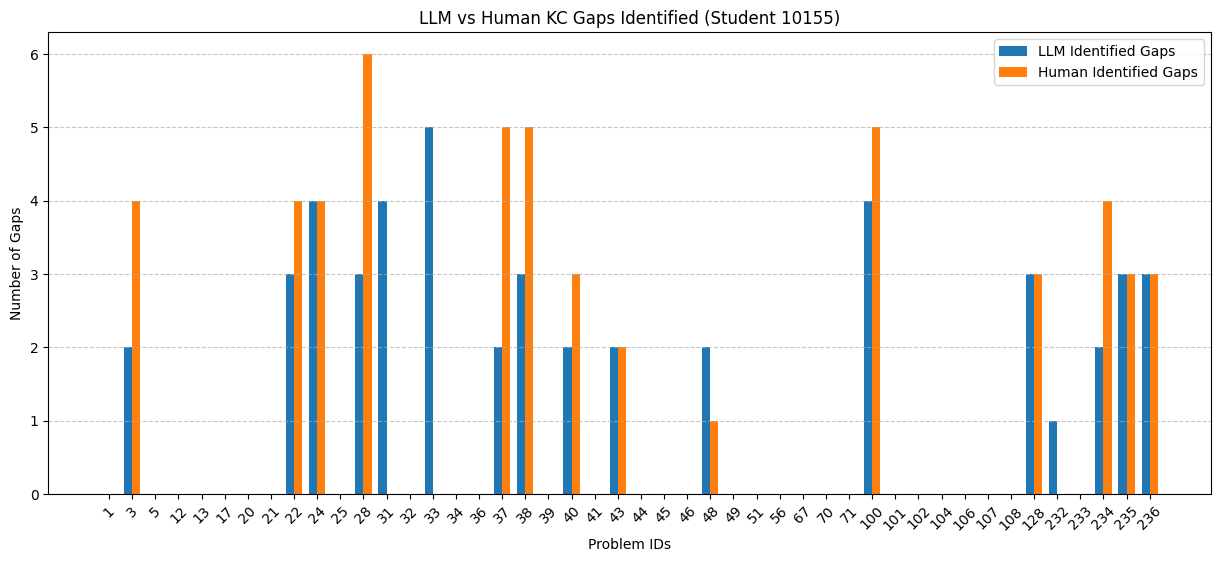

Comparison Summary Table:
PID        | LLM Count  | Human Count 
------------------------------------
1          | 0          | 0           
3          | 2          | 4           
5          | 0          | 0           
12         | 0          | 0           
13         | 0          | 0           
17         | 0          | 0           
20         | 0          | 0           
21         | 0          | 0           
22         | 3          | 4           
24         | 4          | 4           
25         | 0          | 0           
28         | 3          | 6           
31         | 4          | 0           
32         | 0          | 0           
33         | 5          | 0           
34         | 0          | 0           
36         | 0          | 0           
37         | 2          | 5           
38         | 3          | 5           
39         | 0          | 0           
40         | 2          | 3           
41         | 0          | 0           
43         | 2          | 2           
4

In [ ]:
import numpy as np

# Load local human annotations for comparison
if os.path.exists(HUMAN_ANNOTATIONS_PATH):
    with open(HUMAN_ANNOTATIONS_PATH, 'r') as f:
        human_data = json.load(f)
    human_annotations = human_data.get('annotations', {})
else:
    print(f"Human annotation file not found: {HUMAN_ANNOTATIONS_PATH}")
    human_annotations = {}

# Prepare comparison data
pids = list(llm_results.keys())
problem_labels = [str(pid) for pid in pids]
llm_counts = [len(llm_results[pid]['gaps']) for pid in pids]
human_counts = [len(human_annotations.get(str(pid), {}).get('gaps', [])) for pid in pids]

# Plot comparison chart
plt.figure(figsize=(15, 6))
x = np.arange(len(pids))
width = 0.35

plt.bar(x - width/2, llm_counts, width, label='LLM Identified Gaps')
plt.bar(x + width/2, human_counts, width, label='Human Identified Gaps')

plt.xlabel('Problem IDs')
plt.ylabel('Number of Gaps')
plt.title(f'LLM vs Human KC Gaps Identified (Student {STUDENT_ID})')
plt.xticks(x, problem_labels, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig(os.path.join(VIZ_FOLDER, f"student_{STUDENT_ID}_llm_vs_human_gaps.png"))
plt.show()

# Print detailed comparison summary
print("Comparison Summary Table:")
print(f"{'PID':<10} | {'LLM Count':<10} | {'Human Count':<12}")
print("-" * 36)
for pid, llm_c, hum_c in zip(problem_labels, llm_counts, human_counts):
    print(f"{pid:<10} | {llm_c:<10} | {hum_c:<12}")